# 第33课 · 造出声音的原子 — 亲手实现正弦波（sine wave）x[n]=A·sin(2πfn/sr)

**目标**：实现 `x[n] = A·sin(2π·f·n/sr)`，手写每一步，再用 `np.allclose` 与参考逐点对齐。

> **与 L04 的关系**：公式同一套；L04 的 `sinusoid(t,A,f,phi)` 吃时间数组且可调相位，本课 `my_sine` 按 **freq / duration / sample_rate** 对齐仓库测试信号。两套 API 不冲突。

`aurora.audio.sine` 是后续 STFT / Mel 的测试音来源——`my_sine` 写的就是同一公式。

← **上一课**　[L32 · 给声音标上时刻](L32_numpy_signals.ipynb)

> 上节课学习了 **给声音标上时刻**：用 np.arange / linspace 造出 16kHz 时间轴，为每个采样点盖上时间戳。  
> 本课将探讨 **正弦波生成**。

## 本课剧情：正弦波是声音的原子

物理学有个惊人结论：**任何声音都能分解为若干正弦波之和**（这就是傅里叶定理）。  
钢琴中央 C（261 Hz）、吉他弦声、人的嗓音——本质上都是不同频率、不同振幅的正弦波叠加。

正弦波的公式：

$$x[n] = A \cdot \sin\!\left(2\pi f \cdot \frac{n}{f_s}\right)$$

读法：在第 `n` 个采样点，圆圈已经转了 `2πf·n/fₛ` 弧度，`sin` 取这个角度的投影，乘以振幅 `A`。

| 变量 | 含义 | 典型值 |
|---|---|---|
| `f` | 频率（Hz），决定音调高低 | 440（钢琴 A4） |
| `fₛ` | 采样率（Hz），决定时间分辨率 | 16000 或 44100 |
| `A` | 振幅，决定响度 | 1.0（归一化） |
| `n` | 采样点编号 = `np.arange(N)` | 0, 1, 2, ..., N-1 |

本课任务：实现 `my_sine(freq, duration, sample_rate)` 并与 `aurora.audio.sine`（Aurora 的生产实现）逐点对比。

## 1. 导入工具 + 仓库的"标准答案"

这一段是为了让你一边写自己的版本，一边随时拿仓库版本对照。学习时最怕“只看答案，不知道答案为什么长这样”。所以我们会先把参考实现摆在旁边，再逐步拆公式。


## 铺垫：时间、频率、弧度之间的魔法

在进入代码前，我们需要理解一个关键的转换：**如何把"时间"翻译成"圆上的角度"。**

### 从采样率到时间间隔

采样率 `sr = 8 Hz` 是什么意思？"每秒 8 个点"。换句话说，相邻两个点之间的时间间隔是 `1/sr = 1/8 = 0.125 秒`。

如果你现在处于第 `n` 个采样点（`n = 0, 1, 2, ...`），对应的时间是：
$$t[n] = n \times \frac{1}{sr} = \frac{n}{sr}$$

比如 `sr=8` 时：
- `n=0` → `t=0` 秒
- `n=2` → `t=2/8=0.25` 秒  
- `n=4` → `t=0.5` 秒

这不是魔术，只是"点的编号"乘以"每点的时间宽度"。

### 从频率到圆周转速

频率 `f = 1 Hz` 的意思是"每秒重复 1 次"，也就是"每秒转 1 圈"。

1 圈 = `2π` 弧度（这是圆周的定义，周长 = `2πr`，弧度 = 周长/半径）。

所以每秒转过的弧度是 `2π × f` 弧度/秒。

### 把时间转成圆周转过的角度

如果已经过了 `t` 秒，而且每秒转 `2πf` 弧度，那么总共转过的角度就是：
$$\text{angle}[n] = (2\pi f) \times t[n] = 2\pi f \times \frac{n}{sr}$$

这正是公式中 `2π·f·n/sr` 的来源。不是"显然"，而是**时间 → 圆周位置的直接转换。**

### sin 为什么能代表声波？

圆上的点，用坐标 `(cos θ, sin θ)` 表示。垂直轴的投影就是 `sin θ`。当你转圆圈时，垂直方向的数值在 `-1` 和 `1` 之间来回摇摆，这就像声波在动态麦克风中上下振动一样。这就是**为什么我们用 sin 来生成声波。**

（如果你用 `cos` 也行，只是相位差了 90°，听起来一样，但图形会错开。）

## 实验入口：把声音拆成可观察的数组

用 `sample_rate=8`、`duration=1.0`、`freq=2.0` 生成 8 个采样点，每一步的中间量都打印出来，可以直接看到 `n`、`t`、`angle`、`wave` 的数值对应关系。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
from aurora.audio import sine as reference_sine  # 仓库实现 = 你的对照答案
print('就绪')

就绪


## 动手观察：序列怎样一步步变成信号

观察 `n`、`t`、`angle` 三个中间数组：`angle` 是 `t` 乘以 `2π·freq`，当 `freq=2` 时，1 秒内 `angle` 从 0 走到 4π，对应两个完整周期。

In [3]:
import numpy as np

sample_rate = 8
duration = 1.0
freq = 2.0
N = int(duration * sample_rate)
n = np.arange(N)
t = n / sample_rate
angle = 2 * np.pi * freq * t
wave = np.sin(angle)

print('N =', N)
print('采样点编号 n =', n)
print('时间轴 t =', np.round(t, 3))
print('角度 angle =', np.round(angle, 3))
print('sin(angle) =', np.round(wave, 3))


N = 8
采样点编号 n = [0 1 2 3 4 5 6 7]
时间轴 t = [0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875]
角度 angle = [ 0.     1.571  3.142  4.712  6.283  7.854  9.425 10.996]
sin(angle) = [ 0.  1.  0. -1. -0.  1.  0. -1.]


## 代码实验：遍历频率、振幅和相位

`freq` 加倍时，相同时间段内的过零点数量也加倍；`amplitude` 只改变数值范围，不影响波形形状。

## 追问："形状不变"到底是什么意思？振幅跟"响度"又是什么关系？

上一段说"`amplitude` 只改变数值范围，不影响波形形状"，第一次读到这句话很容易犯嘀咕：如果画两条振幅不同的正弦波，一条上下摆动很大、一条摆动很小，**眼睛看到的明明不一样**，凭什么还说"形状相同"？这里我们把"形状"这个词说精确一点。

### "形状相同"精确指的是什么

这里的"形状"**只**指两件事：

1. **波动的快慢**（频率）——每秒重复摆动多少次
2. **什么时刻到达最高点/最低点**（相位）——波峰、波谷出现在哪个采样点上

**不包括**摆动范围有多大——那是振幅单独决定的，是另一件事。

打个比方：把一张照片整体放大或缩小，图案本身（人脸五官的相对位置、比例）完全没变，变的只是整张照片的尺寸。振幅就是这里的"缩放倍数"：

$$x_A[n] = A \cdot \sin(2\pi f \cdot n/f_s), \qquad x_1[n] = 1 \cdot \sin(2\pi f \cdot n/f_s)$$

两者其实是同一个函数按倍数缩放：`x_A[n] = A · x_1[n]`。对比一下：

- 波动的快慢完全相同——用的是同一个 `f`、同一个 `sr`
- 到达最高点的时刻完全相同——比如两条波都在同一个 `n` 处翻上峰值
- 唯一变化的是数值被整体拉伸或压缩了 `A` 倍（"高度"变了，不是"节奏"变了）

这就是为什么我们说它们"形状相同"——**相同的周期和相位，只是不同的幅度**，就像同一张照片的两个不同尺寸的打印件。

### 那振幅跟"响度"到底有没有关系？

这是个很自然的音频学问题：如果振幅只是数学上的缩放系数，那它跟耳朵听到的"响不响"有没有关系？

答案是：**有，而且是最直接的物理关系。**

数字音频最终要送进音箱，驱动里面的振膜（膜片）来回运动。数组里的每个数值，本质上就是"振膜在这一时刻应该移动到的位置"。数值越大，振膜的位移越大、振动越剧烈，推动空气的力度也越大，耳朵感受到的声音就越"响"。

所以，如果你把 `amplitude` 从 `0.5` 改成 `1.0`，相当于让音箱振膜多动一倍的距离——人耳听到的响度也会明显增大。可以近似地说：

**幅度数值 ≈ 响度强度**（至少在没有压缩、均衡等特殊音频处理的前提下）。

这也呼应了本课开头变量表里的那句话——"`A` | 振幅，决定响度"：振幅不只是数学上的抽象缩放因子，它在物理世界里对应的正是"这个声音有多响"。下面这段代码可以直接听／看到这个对应关系：振幅越大，`min`/`max` 的绝对值越大，波形在竖直方向被拉得越"高"，但过零点的位置（也就是节奏）完全没有变。

In [4]:
import numpy as np

sample_rate = 16
duration = 0.5
t = np.arange(int(duration * sample_rate)) / sample_rate

for freq in [1, 2, 4]:
    wave = np.sin(2 * np.pi * freq * t)
    print(f'freq={freq}Hz ->', np.round(wave, 3))

for amplitude in [0.5, 1.0, 2.0]:
    wave = amplitude * np.sin(2 * np.pi * 2 * t)
    print(f'amplitude={amplitude} -> min={wave.min():.1f}, max={wave.max():.1f}')


freq=1Hz -> [0.    0.383 0.707 0.924 1.    0.924 0.707 0.383]
freq=2Hz -> [ 0.     0.707  1.     0.707  0.    -0.707 -1.    -0.707]
freq=4Hz -> [ 0.  1.  0. -1. -0.  1.  0. -1.]
amplitude=0.5 -> min=-0.5, max=0.5
amplitude=1.0 -> min=-1.0, max=1.0
amplitude=2.0 -> min=-2.0, max=2.0


## 关键概念：完整周期与采样点数

在进入手算例子前，我们需要明确一个常见的混淆：**"一个完整周期需要多少个采样点？"**

### 定义：周期与采样点数的关系

对于频率 `f` Hz 的正弦波，在采样率 `sr` Hz 下：
- **每秒的周期数**是 `f`（比如 `f=440` 表示每秒 440 个周期）
- **每秒的采样点数**是 `sr`（比如 `sr=16000` 表示每秒 16000 个点）
- **每个周期需要的采样点数** = `sr / f`

例如：
- `f=1 Hz, sr=8 Hz` → 每周期 8 个点
- `f=440 Hz, sr=16000 Hz` → 每周期 16000/440 ≈ 36.36 个点（不一定是整数！）

### 完整周期的"起点"和"终点"

这里有个容易卡的地方：如果 `N=8` 个采样点，编号 `n=0,1,2,...,7`，那么：
- 第 0 点对应 `angle=0`，`sin(0)=0`（周期的起点）
- 第 4 点对应 `angle=π`，`sin(π)=0`（半周期，过零）
- 第 7 点对应 `angle=7π/4 ≈ 1.75π`，`sin(7π/4) ≈ -0.707`（还没回到 0！）

**这很关键**：点数组 `n=0~7` 的最后一点（n=7）通常**不会恰好回到起点**（`sin=0`），除非 `sr/f` 正好是整数。这是**截断采样**的自然结果——你的数组有固定长度，最后一个点往往刚好在某个周期的中途。

这不是 bug，这是特性。

## 2. 手算一个采样点

频率 `f=1 Hz`，采样率 `fₛ=8 Hz`，振幅 `A=1`。

**第 0 点** (`n=0`)：角度 = 2π·1·0/8 = 0，x[0] = sin(0) = **0**  
**第 2 点** (`n=2`)：角度 = 2π·1·2/8 = π/2，x[2] = sin(π/2) = **1**（峰值）  
**第 4 点** (`n=4`)：角度 = 2π·1·4/8 = π，x[4] = sin(π) = **0**（过零）  
**第 6 点** (`n=6`)：角度 = 2π·1·6/8 = 3π/2，x[6] = sin(3π/2) = **-1**（谷值）

8 个点恰好完成一个完整周期——因为 `fₛ/f = 8/1 = 8`（奈奎斯特定理：完整一圈需要至少 2 个点）。

> **Aurora 连接**：`aurora.audio.sine` 正是这个公式；它是所有合成音频测试的基础信号，也是 FFT 验证套件（`tests/audio/test_transforms.py`）中"单频纯音"测试用例的信号源。

## 3. ✏️ 你的任务：实现 `my_sine`

这一题最关键的不是公式本身，而是把公式翻译成代码时，知道每个变量在代码里扮演什么角色：

- `freq`：频率，决定波动快慢
- `duration`：时长，决定序列有多长
- `sample_rate`：采样率（sample rate，sr），决定每秒取多少点
- `n` 或 `t`：位置序列，代表每个采样点的编号或时间
- `amplitude`：振幅，决定波形上下摆动的幅度

**推理路线**：
1. 先算出总点数：`N = int(duration * sample_rate)`（截断取整，与仓库 `aurora.audio.sine` 一致），这是返回数组的长度。
2. 生成整数编号序列：`n = np.arange(N)`，从 0 到 N-1，不含端点 N。
3. 把编号换算成角度：`angle = 2*np.pi*freq*n/sample_rate`，其中 `n/sample_rate` 就是每个点的时间 `t`。
4. 返回 `amplitude * np.sin(angle)`——振幅只是一个缩放因子，不影响波形形状。

**参考输入输出**：`freq=1, duration=1, sample_rate=8` → 8 个点，`angle=[0, π/4, π/2, 3π/4, π, 5π/4, 3π/2, 7π/4]`，`sin≈[0, 0.707, 1, 0.707, 0, -0.707, -1, -0.707]`

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。



### 写 `my_sine` 前明确三件事

- 输入：`freq`（Hz）、`duration`（秒）、`sample_rate`（点/秒）、`amplitude`（默认 1.0）
- 关键步骤：`N = int(duration * sample_rate)`，`n = np.arange(N)`，`angle = 2*np.pi*freq*n/sample_rate`
- 返回：长度为 `N` 的 float64 数组，值域 `[-amplitude, amplitude]`

In [5]:
def my_sine(freq, duration, sample_rate, amplitude=1.0):
    # ✏️ TODO: 按公式实现并返回正弦波
    raise NotImplementedError("TODO: 按公式实现并返回正弦波")


## 4. 对答案：和仓库实现逐点比较

这里要看的不只是“有没有报错”，还要看三个层面的对应关系：

- **长度是否一致**：说明你有没有生成正确数量的采样点
- **每个点是否一致**：说明你有没有把公式写对
- **误差是否极小**：说明数值计算里的浮点误差是否在正常范围

如果这里没过，不要急着改 `sin` 本身，先检查 `n` 是不是从 0 开始、`N` 算得对不对、采样率是不是除错了。


## 为什么用 `int()` 而不是 `round()`？

在计算总采样点数 `N = int(duration * sample_rate)` 时，我们用的是 **截断取整** (`int()`)，而不是 **四舍五入** (`round()`)。这个选择有深层的原因。

### 两种取整方式的区别

假设 `duration=0.5 秒, sample_rate=3 Hz`：
- `duration * sample_rate = 1.5`
- `int(1.5) = 1`（截断）
- `round(1.5) = 2`（四舍五入）

哪个更对？

### 从物理意义理解

`duration=0.5 秒` 表示的是"我们要生成这个时长范围内的采样点"。按照 `sr=3 Hz`，时间轴上的采样位置是：
- 第 0 个点：`t=0.0 秒`（在范围内 ✓）
- 第 1 个点：`t=1/3 ≈ 0.333 秒`（在范围内 ✓）
- 第 2 个点：`t=2/3 ≈ 0.667 秒`（**超出范围** ✗ — 大于 0.5）

所以我们能取出来的点数就是 1 个，对应 `int(1.5)=1`。

这被称为 **半开区间** `[0, duration)`：包含起点，不包含终点（超界的部分）。

### 从音频处理的视角

在音频框架中，时间轴的约定通常是"**严格覆盖你指定的时间段，不超出**"。如果你说"生成 0.5 秒的音频"，意思是"给我恰好能放进 0.5 秒里的采样点"，而不是"尽量接近 0.5 秒"。

用 `int()` 保证了这一点。这也是为什么 `aurora.audio.sine` 用的是 `int()`。

### 边缘情况检验

你会在下面的边缘测试中看到 `duration=0.5, sr=3` 的检查，正是为了确保你的实现遵循这个约定。

In [6]:
# ⚡ 形状 + 数值验证（未实现时给出提示而非崩溃）
try:
    freq, dur, sr = 440.0, 1.0, 16000
    mine = my_sine(freq, dur, sr)
    ref = reference_sine(freq, duration=dur, sample_rate=sr)
    max_diff = float(np.max(np.abs(mine - ref)))
    print('我的 shape:', mine.shape, '| 标准 shape:', ref.shape)
    print('最大逐点误差:', f'{max_diff:.2e}')
    assert mine.shape == ref.shape, '长度应一致'
    assert max_diff < 1e-12, f'数值应几乎一致（机器精度级别），当前误差={max_diff:.2e}'
    print('\n✅ 对答案通过：你的正弦波和仓库一致。')
except (NotImplementedError, TypeError):
    print('⚠️  my_sine 尚未实现，请先完成 cell 上方的 TODO，再运行此验证。')
except TypeError as e:
    print(f'❌ 类型错误（my_sine 可能返回了 None）：{e}')


⚠️  my_sine 尚未实现，请先完成 cell 上方的 TODO，再运行此验证。


In [7]:
# ⚡ 边缘测试：覆盖 int() 截断和 amplitude=0 情况
try:
    # 边缘 1：amplitude=0 应返回全零数组
    result_zero = my_sine(freq=440.0, duration=1.0, sample_rate=16000, amplitude=0.0)
    assert np.all(result_zero == 0.0), '❌ amplitude=0 时应返回全零数组'
    print('✅ 边缘1 通过：amplitude=0 返回全零数组')

    # 边缘 2：int() 截断（duration=0.5, sr=3 → int(1.5)=1，round(1.5)=2）
    result_trunc = my_sine(freq=1.0, duration=0.5, sample_rate=3)
    ref_trunc = reference_sine(freq=1.0, duration=0.5, sample_rate=3)
    assert result_trunc.shape == ref_trunc.shape, (
        f'❌ int() 截断测试：shape 不一致，my={result_trunc.shape} vs ref={ref_trunc.shape}\n'
        '   提示：确保用 int(duration * sample_rate) 而非 round()'
    )
    print(f'✅ 边缘2 通过：int截断 duration=0.5,sr=3 → N={result_trunc.shape[0]}（与仓库一致）')
except (NotImplementedError, TypeError):
    print('⚠️  my_sine 尚未实现，完成后再运行边缘测试。')


⚠️  my_sine 尚未实现，完成后再运行边缘测试。


## 5. 画出来看看（前 50 个采样点）

图像能直接显示序列的时间变化。你看到的不是“数组”，而是“这个波在时间上怎么上下摆动”。

前 50 个采样点只是一个很小的窗口，但它能帮你看出：
- 波形是不是连续的
- 振幅是不是对的
- 频率是不是符合预期

如果你愿意，还可以把 `mine[:50]` 和 `ref[:50]` 叠在一起看，这样更容易发现偏差。


In [8]:
import matplotlib.pyplot as plt
try:
    mine
except NameError:
    print('⚠️  my_sine 尚未实现，跳过绘图。完成上方 TODO 后重新运行此格。')
else:
    plt.figure(figsize=(8, 3))
    plt.plot(mine[:50], marker='o', ms=3)
    plt.title('440 Hz sine — first 50 samples')
    plt.xlabel('sample n'); plt.ylabel('amplitude')
    plt.tight_layout(); plt.show()

⚠️  my_sine 尚未实现，跳过绘图。完成上方 TODO 后重新运行此格。


**🎉 完成后**：`git commit -m 'learn: L33 my_sine'`

## 🎨 图示：440Hz 正弦的前 50 个采样点

这一段不是“装饰”，而是 notebook 最强的地方：**把公式变成图，把图再变成直觉**。当你以后写别的波形、别的序列、别的信号处理代码时，这种“先生成、再比较、再可视化”的习惯会一直有用。


## 如何判断图形是"对"的？——对比错误实现

当你画出波形图后，怎样确认它不是巧合相似，而是真的正确？最好的方法是**看一些常见的错误会长什么样**。

### 常见错误及其对应的图形

**错误 1：漏掉 2π，写成 `angle = f * n / sr`**
```
x = np.sin(2 * np.pi * freq * n / sr)  ← 正确
x = np.sin(freq * n / sr)              ← 错误：漏掉 2π
```
效果：波形会扁掉，幅度很小（因为 `freq * n / sr` 只在 0 到 freq 之间变化，远小于 2π）。比如 `freq=440` 时，整个 1 秒的波形看起来几乎是平的。

**错误 2：倒数了，写成 `angle = 2π * freq * sr / n`**
```
x = np.sin(2 * np.pi * freq * n / sr)  ← 正确
x = np.sin(2 * np.pi * freq * sr / n)  ← 错误：分子分母反了（而且 n=0 时会 ZeroDivisionError）
```
效果：会直接崩溃，或者（如果加了保护）出现完全不可识别的噪声。

**错误 3：用了 `round()` 代替 `int()`**
```
N = int(duration * sample_rate)    ← 正确
N = round(duration * sample_rate)  ← 错误（虽然很接近，但边缘情况会暴露）
```
效果：大部分情况看起来一样，但 `np.allclose` 会在对答案时报错。

**错误 4：amplitude 放在了错的位置，比如 `amplitude * angle` 而不是 `amplitude * sin(...)`**
```
x = amplitude * np.sin(angle)  ← 正确
x = np.sin(amplitude * angle)  ← 错误：改变了角度，不只是幅度
```
效果：波形会被"压缩"或"拉伸"，频率看起来完全错了。

### 验证正确性的三个层面

1. **整体形状**：看起来像个连续摇摆的波吗？还是噪声、平线或疯狂震荡？
2. **周期和频率**：在前 50 个点里，应该能看到足够的"上升-下降"循环吗？
3. **振幅范围**：最大值是不是接近 amplitude，最小值是不是接近 -amplitude？

如果三个都对，那你的实现就可能是对的。如果任意一个有问题，重新检查上面的公式。

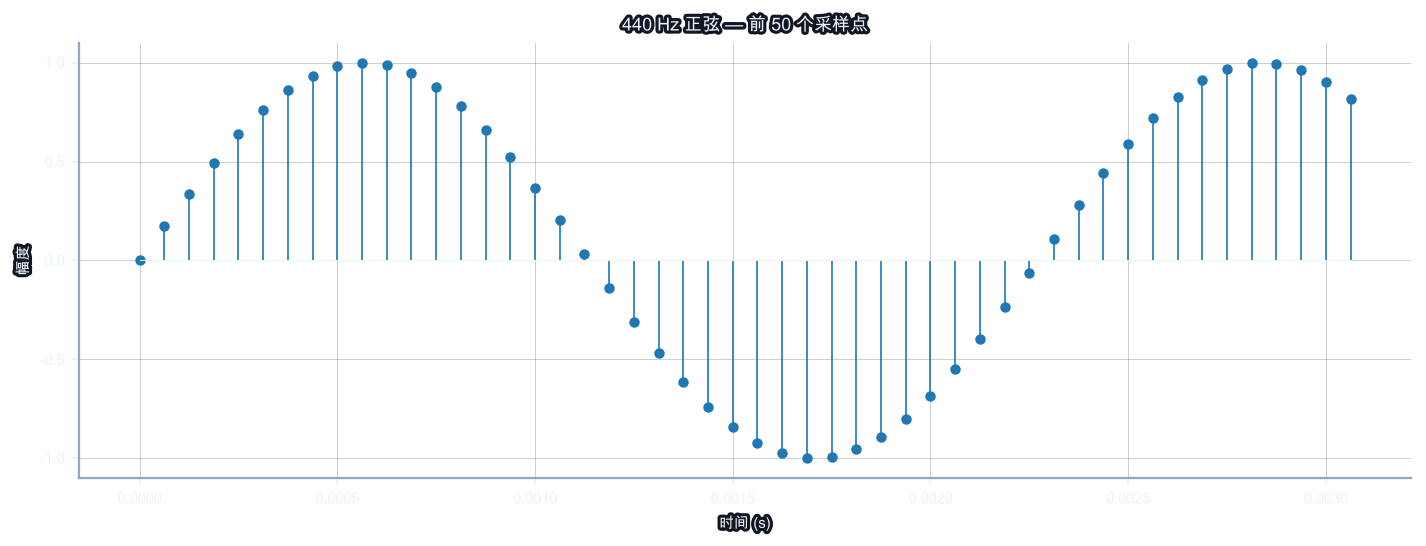

In [9]:
from aurora.audio import sine
import aurora.aviz as aviz; aviz.style()
aviz.waveform(sine(440.0, duration=50/16000, sample_rate=16000), stem=True,
              title='440 Hz 正弦 — 前 50 个采样点');

In [10]:
sr = 32
duration = 1.0
t = np.arange(int(duration * sr)) / sr

for freq in [1, 2, 4, 8]:
    x = np.sin(2*np.pi*freq*t)
    zero_crossings = np.sum(np.diff(np.signbit(x)) != 0)
    print(f'freq={freq:>2}Hz | 前8点={np.round(x[:8], 2)} | 过零次数≈{zero_crossings}')


freq= 1Hz | 前8点=[0.   0.2  0.38 0.56 0.71 0.83 0.92 0.98] | 过零次数≈1
freq= 2Hz | 前8点=[0.   0.38 0.71 0.92 1.   0.92 0.71 0.38] | 过零次数≈3
freq= 4Hz | 前8点=[ 0.    0.71  1.    0.71  0.   -0.71 -1.   -0.71] | 过零次数≈7
freq= 8Hz | 前8点=[ 0.  1.  0. -1. -0.  1.  0. -1.] | 过零次数≈15


## Nyquist 定理的直观理解

你可能在课程中听过"奈奎斯特频率"或"Nyquist 频率 = sr/2"，但这到底是什么意思呢？

### 问题：如何识别一个波形？

想象你现在看采样点序列 `[1, 0, -1, 0, 1, 0, -1, 0, ...]`，只有这些离散的数字。你能从中判断出"这是什么频率的正弦波"吗？

答案是：**需要足够密集的采样点。**

如果两个相邻采样点之间的时间太长，中间可能发生了完整的"上升和下降"，你的采样器完全抓不住。

### 极限：最少需要多少个点？

对于一个正弦波，完整的"上升-下降"周期需要至少多少个点来描述？

想象最坏情况：你在 `angle=0`（`sin=0`）采样，然后立刻在 `angle=π`（`sin=0`）再采样。这两个点都是 0，看起来像"完全没有波"。但中间其实转了 180°，波峰在 `angle=π/2` 处被你完全错过了。

要保证**不错过任何峰值**，你至少需要：
- 一个点在周期的"上升部分"（比如 `sin > 0`）
- 一个点在周期的"下降部分"（比如 `sin < 0`）

这样才能从采样点的正负变化看出"有波在这里"。

### 数学表述：Nyquist 频率

采样率 `sr` 下，最高可以准确表示的频率是 `sr/2`。

为什么？因为每个完整周期需要至少 2 个采样点：
$$\text{周期点数} = \frac{sr}{f} \geq 2$$
$$f \leq \frac{sr}{2}$$

当 `f = sr/2` 时，每周期恰好 2 个点，比如 `[1, -1, 1, -1, ...]`，这是极限——已经没法再用两个采样点的组合表示更高的频率了。

### 超过 Nyquist 会发生什么？

如果 `f > sr/2`，你的采样器会把这个高频信号"折叠"成一个低频信号。这叫 **混叠**（aliasing），是 L34 的主题。

比如 `f=16 Hz, sr=32 Hz`（Nyquist=16 Hz），边界正好。再高一点 `f=17 Hz`，看起来就像 `15 Hz` 了——这就是"折叠"。

## 参数实验：Nyquist 频率的采样极限

把 `freq` 改成 `sample_rate/2`（Nyquist 频率），观察输出交替为 `[0, 1, 0, -1, ...]` 或 `[0, 0, 0, ...]`（取决于相位）——每个完整周期只剩两个采样点，正好够表示，但已是极限。这是 L34（混叠）的预习：当 `freq > sample_rate/2` 时，采样点不够，高频成分会被折叠成低频噪声。

In [11]:
sr = 32
duration = 1.0
t = np.arange(int(duration * sr)) / sr

for freq in [1, 2, 4, 8, 16]:  # 16 = sr/2 = Nyquist 频率
    x = np.sin(2*np.pi*freq*t)
    print(f'freq={freq:>2}Hz | 前8点={np.round(x[:8], 2)} | max={x.max():.1f}')


freq= 1Hz | 前8点=[0.   0.2  0.38 0.56 0.71 0.83 0.92 0.98] | max=1.0
freq= 2Hz | 前8点=[0.   0.38 0.71 0.92 1.   0.92 0.71 0.38] | max=1.0
freq= 4Hz | 前8点=[ 0.    0.71  1.    0.71  0.   -0.71 -1.   -0.71] | max=1.0
freq= 8Hz | 前8点=[ 0.  1.  0. -1. -0.  1.  0. -1.] | max=1.0
freq=16Hz | 前8点=[ 0.  0. -0.  0. -0.  0. -0.  0.] | max=0.0


## 本课收束

现在可以用 `my_sine(freq, duration, sample_rate)` 生成任意频率的正弦波。

`np.allclose(my_sine(...), reference_sine(...))` 返回 `True`，说明两个实现用的是同一套公式。

`aurora.audio.sine` 在 STFT 和 mel 特征提取的测试中生成标准信号，`my_sine` 是它的手动复现。

下一课（L34）会对这条正弦波降低采样率，观察高于 Nyquist 的频率如何被折叠到低频。

In [12]:
# 小检查：从短序列开始，确认每一步输出
import numpy as np

sample_rate = 8
duration = 1.0
freq = 1.0
N = round(duration * sample_rate)
n = np.arange(N)
t = n / sample_rate
angle = 2 * np.pi * freq * t
x = np.sin(angle)

print('1) N 应该是多少？', N)
print('2) n 是采样点编号：', n)
print('3) t 是每个点的秒数：', np.round(t, 3))
print('4) angle 是每个点在圆上的角度：', np.round(angle, 3))
print('5) x 是最终波形：', np.round(x, 3))


1) N 应该是多少？ 8
2) n 是采样点编号： [0 1 2 3 4 5 6 7]
3) t 是每个点的秒数： [0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875]
4) angle 是每个点在圆上的角度： [0.    0.785 1.571 2.356 3.142 3.927 4.712 5.498]
5) x 是最终波形： [ 0.     0.707  1.     0.707  0.    -0.707 -1.    -0.707]


## 采样点数目与时间对齐：为什么 int() 的"漂移"不是问题

一个细心的疑问：如果 `sr=16000, duration=1.0`，`N=16000` 个点，那最后一个点的时间是 `(N-1)/sr = 15999/16000 ≈ 0.9999375 秒`，差了 `0.0000625 秒`。这个"漂移"会不会累积成问题？

### 为什么这不是问题

在音频处理中，这个 `1/sr` 级别的漂移是**允许的舍入误差**，原因有三：

1. **采样本身就是离散化**：音频采样的本质就是用有限个时刻的值来近似连续信号。你不可能让最后一个点恰好在 `duration` 时刻——数学上没有"duration+ε"这样的点。

2. **精度远超需要**：`1/16000 ≈ 62.5 微秒` 的漂移，对于人耳可以感知的音频（几毫秒量级）来说完全不可察觉。你自己的音箱或麦克风的误差早就超过这个量级了。

3. **拼接和处理都有冗余**：在实际应用中，音频段落通常会有重叠窗口（比如 STFT），本身就为了消除边界效应。单个段落的尾部误差会被"融合"进去。

### 什么时候需要关心？

只有在极端情况下才需要特别注意：
- 你在做**超高精度的信号对齐**（比如多轨混音，要求纳秒级精度）
- 你在做**长时间累积**（比如 100+ 小时的连续音频处理，每段的小漂移加起来）

这些超出了音频 DSP 入门课的范围。现在，放心地用 `int()` 吧。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## 手工计算的参考表：sin 的关键值

在推导白板问题的答案时，你需要知道这些特殊角的 sin 值。不用死记，只要记住"圆的四分之一"：

| 角度 | 弧度 | sin 值 |
|---|---|---|
| 0° | 0 | 0 |
| 90° | π/2 | 1（波峰）|
| 180° | π | 0（过零） |
| 270° | 3π/2 | -1（波谷）|
| 360° | 2π | 0（回到起点） |

在白板问题 1 中，`freq=1, sr=8` 时，每个采样点的角度间隔是 `2π/8 = π/4`（45°）。所以 `n=0,1,2,...,7` 对应的角度依次是 `0, π/4, π/2, 3π/4, π, 5π/4, 3π/2, 7π/4`。

关键点是**最后一个点 n=7** 对应的角度 `7π/4` 还没有回到 `2π`，所以 `sin(7π/4) ≠ 0`。这很自然。

## ✏️ 白板挑战：正弦波手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：`freq=1 Hz, sample_rate=8 Hz, amplitude=1, duration=1s`
- N = ?（总点数）
- x[0] = sin(?) = ?
- x[2] = sin(?) = ?（应该是峰值）
- x[4] = sin(?) = ?（又回零？）

**问 2**：`freq=440 Hz, sample_rate=16000 Hz, duration=1s`
- N = ?
- x[0] = ?
- 完成一个周期需要多少个采样点？（`fₛ/f = ?`）

**问 3**：振幅 `A=0.5` 时，波形数值范围是 `[?, ?]`

**问 4**：为什么 `x[-1] ≠ 0`？
- 提示：最后一个采样点在 n=N−1，它的角度是 `2π·freq·(N-1)/sr`
- 当 freq=440, sr=16000, N=16000 时，这个角度等于 `2π·440 - 2π·440/16000`
- 换句话说，它比 `2π·440`（整周期的终点）少转了 `2π·440/16000 ≈ 0.172 弧度`
- 所以 `sin(这个角度) ≠ 0`

推导完成后运行下面格对答案。

In [13]:
# ✏️ 对答案格
import numpy as np

# 问1：freq=1, sr=8, dur=1
freq, sr, dur = 1.0, 8, 1.0
N1 = round(dur * sr)
assert N1 == 8
n1 = np.arange(N1)
x1 = np.sin(2 * np.pi * freq * n1 / sr)
assert np.isclose(x1[0], 0.0, atol=1e-15)
assert np.isclose(x1[2], 1.0, atol=1e-15), f"x[2] 应=1（峰值），得到 {x1[2]:.6f}"
assert np.isclose(x1[4], 0.0, atol=1e-14), f"x[4] 应=0（过零），得到 {x1[4]:.2e}"
print(f"Q1 ✅  N={N1}，x={np.round(x1, 4)}")
print(f"      x[2]={x1[2]:.4f}（峰值），x[4]={x1[4]:.2e}（过零）")

# 验证 my_sine 一致性
try:
    mine = my_sine(freq, dur, sr)
    assert np.allclose(mine, x1, atol=1e-12)
    print(f"      my_sine 与手算结果吻合 ✅")
except (NotImplementedError, TypeError):
    print("⬜ Q1：请先实现 my_sine()，再运行对答案格")

# 问2：440 Hz, sr=16000
N2 = round(1.0 * 16000)
assert N2 == 16000
samples_per_cycle = 16000 / 440
assert np.isclose(samples_per_cycle, 36.36, atol=0.01)
print(f"Q2 ✅  N=16000，每周期 fₛ/f=16000/440≈{samples_per_cycle:.2f} 个采样点")

# 问3：amplitude=0.5
x3 = 0.5 * np.sin(2 * np.pi * 1.0 * np.arange(8) / 8)
assert np.max(x3) <= 0.5 + 1e-12 and np.min(x3) >= -0.5 - 1e-12
print(f"Q3 ✅  振幅=0.5，数值范围=[{np.min(x3):.4f}, {np.max(x3):.4f}]")

# 问4：非整数频率时 x[-1] 不回零
x4 = np.sin(2 * np.pi * 440 * np.arange(16000) / 16000)
last = x4[-1]
print(f"Q4 ✅  440Hz/16000Hz → x[-1]={last:.6f}≠0（最后一点在 n=N-1，比整周期终点早一个采样间隔）")
print(f"      x[-1] 的角度 = 2π·440·15999/16000 = 2π·440 − 2π·440/16000，不是 2π 的整数倍")
print("\n🎉 正弦波白板挑战通过！x[n]=A·sin(2πf·n/fₛ) 已内化。")

Q1 ✅  N=8，x=[ 0.      0.7071  1.      0.7071  0.     -0.7071 -1.     -0.7071]
      x[2]=1.0000（峰值），x[4]=1.22e-16（过零）
⬜ Q1：请先实现 my_sine()，再运行对答案格
Q2 ✅  N=16000，每周期 fₛ/f=16000/440≈36.36 个采样点
Q3 ✅  振幅=0.5，数值范围=[-0.5000, 0.5000]
Q4 ✅  440Hz/16000Hz → x[-1]=-0.171929≠0（最后一点在 n=N-1，比整周期终点早一个采样间隔）
      x[-1] 的角度 = 2π·440·15999/16000 = 2π·440 − 2π·440/16000，不是 2π 的整数倍

🎉 正弦波白板挑战通过！x[n]=A·sin(2πf·n/fₛ) 已内化。


In [ ]:
# ✏️ 本课自评
l33_review = {
    "sine_formula":           None,  # 记住 x[n]=A·sin(2πf·n/fₛ)？True/False
    "my_sine_implemented":    None,  # my_sine 实现并通过 allclose 断言？True/False
    "samples_per_cycle":      None,  # 理解每周期采样数 = fₛ/f？True/False
    "nyquist_intuition":      None,  # 知道 f < fₛ/2 才能正常采样（Nyquist）？True/False
    "whiteboard_passed":      None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l33_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l33_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L33 全部通关！进入 L34：Nyquist 定理与混叠')

---

→ **下一课**　[L34 · Nyquist 定理与混叠](L34_aliasing.ipynb)

> 下节课将学习 **Nyquist 定理与混叠**：6kHz 正弦波被 8kHz 采样后会变成什么。